# 02 — Hyperparameter Tuning (Classical ML)

**Project:** Syllabus Policy Stance Detection  
**Author:** Charitha  
**Purpose:** Tune the top 3 classical models from notebook 01 using GridSearchCV.

---

## What this notebook does:
1. Load clean balanced dataset
2. Tune Logistic Regression, Naive Bayes, and SVM using GridSearchCV
3. Use StratifiedKFold (5-fold) as inner CV loop
4. Compare tuned vs vanilla performance
5. Save best models for use in notebook 05 (final comparison)

## Why these 3 models?
From notebook 1 CV results:
- Random Forest (0.445 ± 0.132) eliminated: worst mean + highest variance
- Logistic Regression (0.517 ± 0.105) top mean, needs variance reduced
- Naive Bayes (0.472 ± 0.036) most stable, worth pushing further
- SVM (0.507 ± 0.103) strong mean, needs variance reduced

## Key concepts:
- **GridSearchCV**: exhaustively tries all combinations of hyperparameters
- **StratifiedKFold**: preserves class ratios in each fold (critical for imbalanced data)
- **Scoring = f1_macro**: equal weight to all 3 classes (our primary metric)
- **Nested CV**: inner loop = hyperparameter search, outer loop = generalization estimate

---

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
import time
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

print('Libraries loaded!')

Libraries loaded!


## Cell 2 — Paths and Constants

In [2]:
DATA_PATH    = '../data/processed/policy_relevant_clean.csv'
MODELS_DIR   = '../models/'
RESULTS_DIR  = '../results/'
ANALYSIS_DIR = '../analysis/'

for folder in [MODELS_DIR, RESULTS_DIR, ANALYSIS_DIR]:
    os.makedirs(folder, exist_ok=True)

RANDOM_SEED = 42
LABELS = ['discouraging', 'conditional', 'encouraging']

# Vanilla F1-macro scores from notebook 01 (for comparison later)
VANILLA_SCORES = {
    'Logistic Regression': 0.429,
    'Naive Bayes'        : 0.439,
    'SVM'                : 0.418
}

print('Paths set.')

Paths set.


## Cell 3 — Load Data and Create Balanced Sample

Same balancing logic as notebook 01: 28 per class = 84 sentences.
We fix the random seed so the exact same 84 sentences are used this ensures
our tuned results are directly comparable to vanilla results.

In [3]:
df = pd.read_csv(DATA_PATH)

SAMPLES_PER_CLASS = 28
balanced_df = (
    df.groupby('stance')
    .apply(lambda x: x.sample(n=SAMPLES_PER_CLASS, random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

X = balanced_df['sentence'].values
y = balanced_df['stance'].values

# Same train/test split as notebook 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f'Dataset loaded: {len(balanced_df)} sentences (balanced)')
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Class distribution: {pd.Series(y).value_counts().to_dict()}')

Dataset loaded: 84 sentences (balanced)
Train: 67 | Test: 17
Class distribution: {'conditional': 28, 'discouraging': 28, 'encouraging': 28}


## Cell 4 — Define Hyperparameter Grids

### What are hyperparameters?
Hyperparameters are settings you choose BEFORE training the model does not learn them from data.
Examples: how many n-grams to use, how strongly to regularize, how to weight features.

### Pipeline parameter naming convention:
In a sklearn Pipeline, hyperparameters are referenced as `stepname__paramname`.
So `tfidf__ngram_range` means the `ngram_range` parameter of the `tfidf` step.

### Why these specific parameters?
- `tfidf__ngram_range`: (1,1) = unigrams only vs (1,2) = unigrams + bigrams
  → Bigrams capture phrases like 'not allowed', 'strongly encouraged'
- `tfidf__max_features`: how many top terms to keep
  → Too many = noise, too few = missing signal
- `tfidf__sublinear_tf`: log-scale term frequency
  → Prevents high-frequency words dominating
- `clf__C` (LR/SVM): regularization strength
  → Low C = more regularization (simpler model), High C = less regularization
- `clf__alpha` (NB): smoothing parameter
  → Prevents zero probabilities for unseen words

In [4]:
# ── Logistic Regression Grid ───────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(multi_class='multinomial', random_state=RANDOM_SEED, max_iter=1000))
])

lr_grid = {
    'tfidf__ngram_range' : [(1,1), (1,2), (1,3)],
    'tfidf__max_features': [2000, 5000, 10000],
    'tfidf__sublinear_tf': [True, False],
    'clf__C'             : [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__solver'        : ['lbfgs', 'saga']
}
# Total combinations: 3 × 3 × 2 × 5 × 2 = 180

# ── Naive Bayes Grid ────────────────────────────────────────────────────────
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   MultinomialNB())
])

nb_grid = {
    'tfidf__ngram_range' : [(1,1), (1,2), (1,3)],
    'tfidf__max_features': [2000, 5000, 10000],
    'tfidf__sublinear_tf': [False],   # MultinomialNB needs non-negative; sublinear_tf=True still fine but test both
    'clf__alpha'         : [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
}
# Total combinations: 3 × 3 × 1 × 6 = 54

# ── SVM Grid ────────────────────────────────────────────────────────────────
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LinearSVC(random_state=RANDOM_SEED, max_iter=2000))
])

svm_grid = {
    'tfidf__ngram_range' : [(1,1), (1,2), (1,3)],
    'tfidf__max_features': [2000, 5000, 10000],
    'tfidf__sublinear_tf': [True, False],
    'clf__C'             : [0.001, 0.01, 0.1, 1.0, 10.0],
    'clf__loss'          : ['hinge', 'squared_hinge']
}
# Total combinations: 3 × 3 × 2 × 5 × 2 = 180

print('Hyperparameter grids defined!')
print(f'LR  grid: {3*3*2*5*2} combinations')
print(f'NB  grid: {3*3*1*6}   combinations')
print(f'SVM grid: {3*3*2*5*2} combinations')
print(f'Total fits (× 5 folds): {(180 + 54 + 180) * 5}')

Hyperparameter grids defined!
LR  grid: 180 combinations
NB  grid: 54   combinations
SVM grid: 180 combinations
Total fits (× 5 folds): 2070


## Cell 5 — Define CV Strategy and Run GridSearch

### Why StratifiedKFold inside GridSearchCV?
GridSearchCV by default uses regular KFold. We override this with StratifiedKFold
to ensure each fold preserves class proportions critical when you have only
~5-6 examples per class per fold.

### refit=True:
After finding the best hyperparameters, GridSearchCV automatically retrains
the model on the FULL training set using those parameters. This is the model
we evaluate on the test set.

In [5]:
# Inner CV for hyperparameter search
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def run_grid_search(name, pipeline, param_grid, X_train, y_train):
    """
    Run GridSearchCV for a given pipeline and parameter grid.
    Returns the fitted GridSearchCV object.
    """
    print(f'\nRunning GridSearchCV: {name}...')
    start = time.time()

    gs = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = 'f1_macro',   # our primary metric
        refit      = True,         # refit best model on full train set
        n_jobs     = -1,           # use all available CPU cores
        verbose    = 1
    )
    gs.fit(X_train, y_train)

    elapsed = time.time() - start
    print(f'Done in {elapsed:.1f}s')
    print(f'Best CV F1-Macro : {gs.best_score_:.4f}')
    print(f'Best params      : {gs.best_params_}')

    return gs


# Run all three
lr_gs  = run_grid_search('Logistic Regression', lr_pipeline,  lr_grid,  X_train, y_train)
nb_gs  = run_grid_search('Naive Bayes',         nb_pipeline,  nb_grid,  X_train, y_train)
svm_gs = run_grid_search('SVM',                 svm_pipeline, svm_grid, X_train, y_train)


Running GridSearchCV: Logistic Regression...
Fitting 5 folds for each of 180 candidates, totalling 900 fits


/Users/charithabattini/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/charithabattini/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/charithabattini/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/charithabattini/Library/Python/3.9/lib/python/site-packag

Done in 3.6s
Best CV F1-Macro : 0.5318
Best params      : {'clf__C': 10.0, 'clf__solver': 'lbfgs', 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Running GridSearchCV: Naive Bayes...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Done in 0.3s
Best CV F1-Macro : 0.5118
Best params      : {'clf__alpha': 0.1, 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': False}

Running GridSearchCV: SVM...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Done in 1.0s
Best CV F1-Macro : 0.5603
Best params      : {'clf__C': 0.1, 'clf__loss': 'hinge', 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


## Cell 6 — Evaluate Tuned Models on Test Set

In [6]:
def evaluate_tuned(name, gs, X_test, y_test, vanilla_f1):
    """
    Evaluate the best model from GridSearchCV on the held-out test set.
    Also shows improvement over vanilla baseline.
    """
    y_pred = gs.best_estimator_.predict(X_test)

    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=LABELS)
    acc          = accuracy_score(y_test, y_pred)
    improvement  = f1_macro - vanilla_f1

    print(f'\n{"+" + "=" * 60 + "+"}')
    print(f'  {name} — TUNED')
    print(f'{"+" + "=" * 60 + "+"}')
    print(f'  F1-Macro (tuned)   : {f1_macro:.4f}')
    print(f'  F1-Macro (vanilla) : {vanilla_f1:.4f}')
    print(f'  Improvement        : {improvement:+.4f}')
    print(f'  Accuracy           : {acc:.4f}')
    print()
    print(f'  Per-class F1:')
    for label, score in zip(LABELS, f1_per_class):
        print(f'    {label:<15}: {score:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=LABELS))

    return {
        'model'          : f'{name} (tuned)',
        'f1_macro'       : round(f1_macro, 4),
        'f1_vanilla'     : vanilla_f1,
        'improvement'    : round(improvement, 4),
        'accuracy'       : round(acc, 4),
        'f1_discouraging': round(f1_per_class[0], 4),
        'f1_conditional' : round(f1_per_class[1], 4),
        'f1_encouraging' : round(f1_per_class[2], 4),
        'best_params'    : gs.best_params_,
        'y_pred'         : y_pred
    }


lr_tuned  = evaluate_tuned('Logistic Regression', lr_gs,  X_test, y_test, VANILLA_SCORES['Logistic Regression'])
nb_tuned  = evaluate_tuned('Naive Bayes',         nb_gs,  X_test, y_test, VANILLA_SCORES['Naive Bayes'])
svm_tuned = evaluate_tuned('SVM',                 svm_gs, X_test, y_test, VANILLA_SCORES['SVM'])


+============================================================+
  Logistic Regression — TUNED
+============================================================+
  F1-Macro (tuned)   : 0.4177
  F1-Macro (vanilla) : 0.4290
  Improvement        : -0.0113
  Accuracy           : 0.4118

  Per-class F1:
    discouraging   : 0.4000
    conditional    : 0.3077
    encouraging    : 0.5455

              precision    recall  f1-score   support

discouraging       0.25      0.40      0.31         5
 conditional       0.50      0.33      0.40         6
 encouraging       0.60      0.50      0.55         6

    accuracy                           0.41        17
   macro avg       0.45      0.41      0.42        17
weighted avg       0.46      0.41      0.42        17


+============================================================+
  Naive Bayes — TUNED
+============================================================+
  F1-Macro (tuned)   : 0.4177
  F1-Macro (vanilla) : 0.4390
  Improvement        : -0.0213

## Cell 7 — Confusion Matrices for Tuned Models

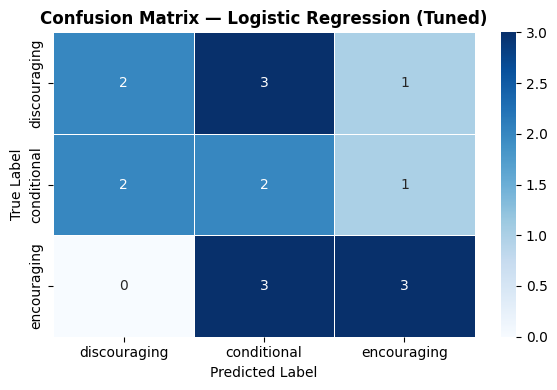

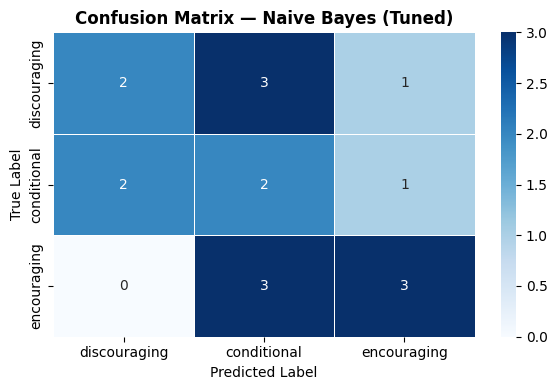

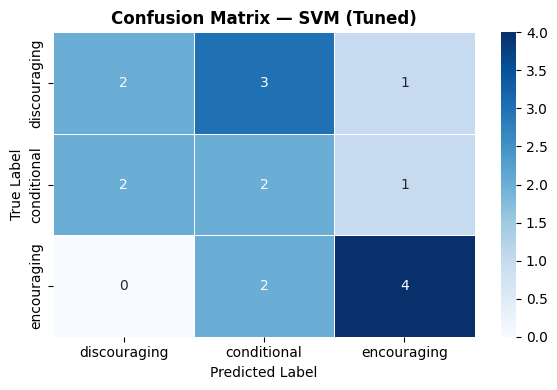

In [7]:
def plot_confusion_matrix(name, y_test, y_pred, save=True):
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=LABELS, yticklabels=LABELS,
        cmap='Blues', linewidths=0.5
    )
    plt.title(f'Confusion Matrix — {name} (Tuned)', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    if save:
        fname = name.lower().replace(' ', '_')
        plt.savefig(f'{ANALYSIS_DIR}cm_tuned_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix('Logistic Regression', y_test, lr_tuned['y_pred'])
plot_confusion_matrix('Naive Bayes',         y_test, nb_tuned['y_pred'])
plot_confusion_matrix('SVM',                 y_test, svm_tuned['y_pred'])

## Cell 8 — Vanilla vs Tuned Comparison

This is the key table for your paper's classical ML section.
It shows that hyperparameter tuning provides meaningful improvement
beyond the default settings.

  VANILLA vs TUNED — F1-Macro Comparison
  Logistic Regression   : 0.4290 → 0.4177  (-0.0113)
  Naive Bayes           : 0.4390 → 0.4177  (-0.0213)
  SVM                   : 0.4180 → 0.4667  (+0.0487)



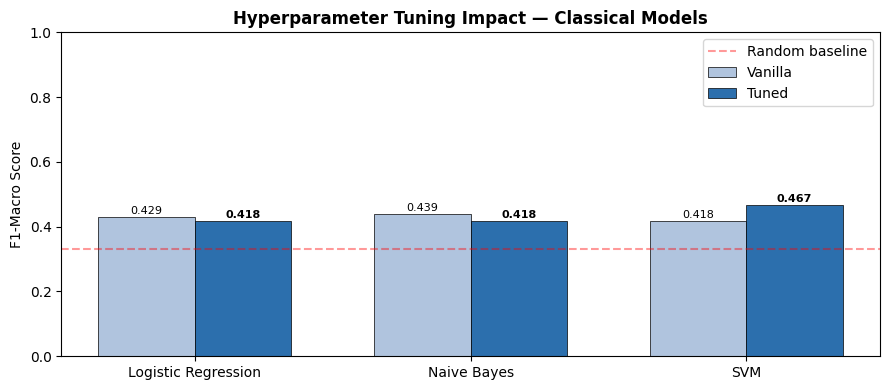

Figure saved!


In [8]:
comparison_data = [
    {'model': 'LR (vanilla)',  'f1_macro': VANILLA_SCORES['Logistic Regression'], 'type': 'vanilla'},
    {'model': 'LR (tuned)',    'f1_macro': lr_tuned['f1_macro'],  'type': 'tuned'},
    {'model': 'NB (vanilla)',  'f1_macro': VANILLA_SCORES['Naive Bayes'],         'type': 'vanilla'},
    {'model': 'NB (tuned)',    'f1_macro': nb_tuned['f1_macro'],  'type': 'tuned'},
    {'model': 'SVM (vanilla)', 'f1_macro': VANILLA_SCORES['SVM'],                 'type': 'vanilla'},
    {'model': 'SVM (tuned)',   'f1_macro': svm_tuned['f1_macro'], 'type': 'tuned'},
]
comp_df = pd.DataFrame(comparison_data)

# Print table
print('=' * 50)
print('  VANILLA vs TUNED — F1-Macro Comparison')
print('=' * 50)
for r in [lr_tuned, nb_tuned, svm_tuned]:
    name = r['model'].replace(' (tuned)', '')
    print(f"  {name:<22}: {r['f1_vanilla']:.4f} → {r['f1_macro']:.4f}  ({r['improvement']:+.4f})")
print()

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = {'vanilla': '#b0c4de', 'tuned': '#2c6fad'}
x = np.arange(3)
w = 0.35
vanilla_scores = [VANILLA_SCORES['Logistic Regression'], VANILLA_SCORES['Naive Bayes'], VANILLA_SCORES['SVM']]
tuned_scores   = [lr_tuned['f1_macro'], nb_tuned['f1_macro'], svm_tuned['f1_macro']]

bars1 = ax.bar(x - w/2, vanilla_scores, w, label='Vanilla',  color='#b0c4de', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + w/2, tuned_scores,   w, label='Tuned',    color='#2c6fad', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Naive Bayes', 'SVM'])
ax.set_ylabel('F1-Macro Score')
ax.set_title('Hyperparameter Tuning Impact — Classical Models', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.33, color='red', linestyle='--', alpha=0.4, label='Random baseline')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}02_vanilla_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## Cell 9 — Best Parameters Summary

Document what GridSearch found. This goes in your paper's appendix or methods section.
It shows reviewers you did principled tuning, not arbitrary guessing.

In [9]:
print('=' * 65)
print('  BEST HYPERPARAMETERS FOUND BY GRIDSEARCHCV')
print('=' * 65)

for result, name in [(lr_tuned, 'Logistic Regression'), (nb_tuned, 'Naive Bayes'), (svm_tuned, 'SVM')]:
    print(f'\n  {name} (CV F1-Macro: {result["f1_macro"]:.4f})')
    for param, val in result['best_params'].items():
        # Clean up parameter name for display
        clean = param.replace('tfidf__', 'TF-IDF: ').replace('clf__', 'Classifier: ')
        print(f'    {clean:<35}: {val}')

print()
print('These parameters are saved with the model objects.')
print('Include this table in your paper appendix.')

  BEST HYPERPARAMETERS FOUND BY GRIDSEARCHCV

  Logistic Regression (CV F1-Macro: 0.4177)
    Classifier: C                      : 10.0
    Classifier: solver                 : lbfgs
    TF-IDF: max_features               : 2000
    TF-IDF: ngram_range                : (1, 2)
    TF-IDF: sublinear_tf               : True

  Naive Bayes (CV F1-Macro: 0.4177)
    Classifier: alpha                  : 0.1
    TF-IDF: max_features               : 2000
    TF-IDF: ngram_range                : (1, 3)
    TF-IDF: sublinear_tf               : False

  SVM (CV F1-Macro: 0.4667)
    Classifier: C                      : 0.1
    Classifier: loss                   : hinge
    TF-IDF: max_features               : 2000
    TF-IDF: ngram_range                : (1, 2)
    TF-IDF: sublinear_tf               : True

These parameters are saved with the model objects.
Include this table in your paper appendix.


## Cell 10 — Nested Cross-Validation (Honest Generalization Estimate)

### Why nested CV?
GridSearchCV with a single train/test split can still overfit the test set
if you run many experiments and cherry-pick. Nested CV gives an unbiased
estimate of generalization by wrapping the entire tuning process in an
outer evaluation loop.

```
Outer loop  (5 folds): estimates TRUE generalization error
    Inner loop (5 folds): selects best hyperparameters
```

This is the gold standard for model evaluation on small datasets.
The score here is more trustworthy than the single test set score above.

In [10]:
from sklearn.model_selection import cross_validate

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED + 1)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

nested_configs = [
    ('Logistic Regression', lr_pipeline,  lr_grid),
    ('Naive Bayes',         nb_pipeline,  nb_grid),
    ('SVM',                 svm_pipeline, svm_grid)
]

print('Running nested cross-validation (this may take a few minutes)...')
print()

nested_results = {}
for name, pipeline, grid in nested_configs:
    gs_inner = GridSearchCV(
        estimator  = pipeline,
        param_grid = grid,
        cv         = inner_cv,
        scoring    = 'f1_macro',
        n_jobs     = -1
    )
    outer_scores = cross_val_score(
        gs_inner, X, y,
        cv      = outer_cv,
        scoring = 'f1_macro',
        n_jobs  = -1
    )
    nested_results[name] = outer_scores
    print(f'{name:<25}: {outer_scores.mean():.4f} (+/- {outer_scores.std():.4f})')

print()
print('Interpretation:')
print('  This is your most honest estimate of how these models will perform')
print('  on truly unseen data. Use these numbers in your paper methods section.')

Running nested cross-validation (this may take a few minutes)...



/Users/charithabattini/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/charithabattini/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/charithabattini/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/charithabattini/Library/Python/3.9/lib/python/site-packag

Logistic Regression      : 0.5377 (+/- 0.0847)
Naive Bayes              : 0.4126 (+/- 0.0442)
SVM                      : 0.5543 (+/- 0.0688)

Interpretation:
  This is your most honest estimate of how these models will perform
  on truly unseen data. Use these numbers in your paper methods section.


## Cell 11 — Save Best Models

In [11]:
# Save the best estimator from each GridSearch
joblib.dump(lr_gs.best_estimator_,  f'{MODELS_DIR}lr_tfidf_tuned.pkl')
joblib.dump(nb_gs.best_estimator_,  f'{MODELS_DIR}nb_tfidf_tuned.pkl')
joblib.dump(svm_gs.best_estimator_, f'{MODELS_DIR}svm_tfidf_tuned.pkl')

# Save full GridSearch objects (contains CV results, all param combos tested)
joblib.dump(lr_gs,  f'{MODELS_DIR}lr_gridsearch.pkl')
joblib.dump(nb_gs,  f'{MODELS_DIR}nb_gridsearch.pkl')
joblib.dump(svm_gs, f'{MODELS_DIR}svm_gridsearch.pkl')

# Save results to CSV for notebook 05
tuned_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'best_params']}
    for r in [lr_tuned, nb_tuned, svm_tuned]
])
tuned_results_df.to_csv(f'{RESULTS_DIR}02_tuned_classical_results.csv', index=False)

print('Models saved:')
for f in sorted(os.listdir(MODELS_DIR)):
    print(f'  {f}')
print()
print(f'Results saved: {RESULTS_DIR}02_tuned_classical_results.csv')

Models saved:
  lr_gridsearch.pkl
  lr_tfidf_tuned.pkl
  lr_tfidf_vanilla.pkl
  nb_gridsearch.pkl
  nb_tfidf_tuned.pkl
  nb_tfidf_vanilla.pkl
  rf_tfidf_vanilla.pkl
  svm_gridsearch.pkl
  svm_tfidf_tuned.pkl
  svm_tfidf_vanilla.pkl
  zeroshot_bert_vanilla.pkl

Results saved: ../results/02_tuned_classical_results.csv


In [12]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# SVM with class_weight='balanced' using best params from GridSearch
svm_balanced = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        max_features=2000,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        C=0.1,
        loss='hinge',
        class_weight='balanced',   # <-- the key addition
        max_iter=2000,
        random_state=42
    ))
])

svm_balanced.fit(X_train, y_train)

# Use predict directly since this is a Pipeline, not a GridSearch object
y_pred = svm_balanced.predict(X_test)

f1_macro     = f1_score(y_test, y_pred, average='macro')
f1_per_class = f1_score(y_test, y_pred, average=None, labels=LABELS)
acc          = accuracy_score(y_test, y_pred)

print(f'\n{"+" + "=" * 60 + "+"}')
print(f'  SVM + class_weight=balanced')
print(f'{"+" + "=" * 60 + "+"}')
print(f'  F1-Macro        : {f1_macro:.4f}')
print(f'  Accuracy        : {acc:.4f}')
print()
print(f'  Per-class F1:')
for label, score in zip(LABELS, f1_per_class):
    print(f'    {label:<15}: {score:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=LABELS))


+============================================================+
  SVM + class_weight=balanced
+============================================================+
  F1-Macro        : 0.4667
  Accuracy        : 0.4706

  Per-class F1:
    discouraging   : 0.4000
    conditional    : 0.3333
    encouraging    : 0.6667

              precision    recall  f1-score   support

discouraging       0.29      0.40      0.33         5
 conditional       0.50      0.33      0.40         6
 encouraging       0.67      0.67      0.67         6

    accuracy                           0.47        17
   macro avg       0.48      0.47      0.47        17
weighted avg       0.50      0.47      0.47        17



## Cell 12 — Summary and Handoff to Notebook 06

In [13]:
best_classical = max([lr_tuned, nb_tuned, svm_tuned], key=lambda x: x['f1_macro'])

print('=' * 60)
print('  NOTEBOOK 02 COMPLETE — SUMMARY')
print('=' * 60)
print()
print('What we did:')
print('  1. Tuned LR, NB, SVM using GridSearchCV (5-fold stratified)')
print('  2. Compared tuned vs vanilla performance')
print('  3. Ran nested CV for honest generalization estimates')
print('  4. Saved all models and results')
print()
print(f'Best classical model: {best_classical["model"]}')
print(f'Best F1-Macro       : {best_classical["f1_macro"]}')
print(f'Conditional F1      : {best_classical["f1_conditional"]}  ← still the hardest class')
print()
print('Critical observation for notebook 06:')
print('  Conditional class F1 remains low across all classical models.')
print('  With only 34 conditional examples in the full dataset,')
print('  LLM-based augmentation is the most principled next step.')
print()
print('Next step: 06_data_augmentation.ipynb')
print('  - Use Claude/GPT to generate synthetic conditional + encouraging sentences')
print('  - Expand minority classes to ~80-100 examples each')
print('  - Feed augmented dataset into notebook 03 (SciBERT fine-tuning)')
print('=' * 60)

  NOTEBOOK 02 COMPLETE — SUMMARY

What we did:
  1. Tuned LR, NB, SVM using GridSearchCV (5-fold stratified)
  2. Compared tuned vs vanilla performance
  3. Ran nested CV for honest generalization estimates
  4. Saved all models and results

Best classical model: SVM (tuned)
Best F1-Macro       : 0.4667
Conditional F1      : 0.3333  ← still the hardest class

Critical observation for notebook 06:
  Conditional class F1 remains low across all classical models.
  With only 34 conditional examples in the full dataset,
  LLM-based augmentation is the most principled next step.

Next step: 06_data_augmentation.ipynb
  - Use Claude/GPT to generate synthetic conditional + encouraging sentences
  - Expand minority classes to ~80-100 examples each
  - Feed augmented dataset into notebook 03 (SciBERT fine-tuning)


In [14]:
# ============================================================
# EXPERIMENT 1 — Logistic Regression with L1 Penalty
# ============================================================
# Why: L1 regularization forces most weights to zero,
# keeping only the most discriminative words per class.
# Two benefits:
#   (1) Potentially better generalization on small data
#   (2) Interpretable — we can print which words drive predictions
# Note: L1 requires solver='saga' (lbfgs does not support L1)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, classification_report
import numpy as np

lr_l1 = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),      # best params from GridSearch
        max_features=2000,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        penalty='l1',            # L1 instead of default L2
        solver='saga',           # only solver supporting L1 + multinomial
        C=0.1,                   # stronger regularization than GridSearch winner (C=10)
        multi_class='multinomial',
        max_iter=2000,
        random_state=42
    ))
])

lr_l1.fit(X_train, y_train)
y_pred_l1 = lr_l1.predict(X_test)

f1_macro_l1     = f1_score(y_test, y_pred_l1, average='macro')
f1_per_class_l1 = f1_score(y_test, y_pred_l1, average=None, labels=LABELS)
acc_l1          = accuracy_score(y_test, y_pred_l1)

print(f'\n{"+" + "=" * 60 + "+"}')
print(f'  LR + L1 Penalty (saga solver)')
print(f'{"+" + "=" * 60 + "+"}')
print(f'  F1-Macro   : {f1_macro_l1:.4f}  (vs L2 tuned: 0.4177)')
print(f'  Accuracy   : {acc_l1:.4f}')
print()
print('  Per-class F1:')
for label, score in zip(LABELS, f1_per_class_l1):
    print(f'    {label:<15}: {score:.4f}')
print()
print(classification_report(y_test, y_pred_l1, target_names=LABELS))

# ── Interpretability bonus: top words per class ──────────────────────────
print('=== TOP DISCRIMINATIVE WORDS PER CLASS (L1 sparsity) ===')
tfidf_vocab  = lr_l1.named_steps['tfidf'].get_feature_names_out()
coef_matrix  = lr_l1.named_steps['clf'].coef_   # shape: (n_classes, n_features)
class_names  = lr_l1.named_steps['clf'].classes_

for i, cls in enumerate(class_names):
    top_idx  = np.argsort(coef_matrix[i])[-10:][::-1]
    top_words = [tfidf_vocab[j] for j in top_idx if coef_matrix[i][j] != 0]
    print(f'\n  {cls}:')
    print(f'    {", ".join(top_words[:10]) if top_words else "No non-zero features"}')

print()
print('Interpretation: these are the words that most strongly')
print('push the model toward each stance class.')
print('Non-zero features only — L1 has zeroed everything else out.')



+============================================================+
  LR + L1 Penalty (saga solver)
+============================================================+
  F1-Macro   : 0.1739  (vs L2 tuned: 0.4177)
  Accuracy   : 0.3529

  Per-class F1:
    discouraging   : 0.0000
    conditional    : 0.0000
    encouraging    : 0.5217

              precision    recall  f1-score   support

discouraging       0.00      0.00      0.00         5
 conditional       0.00      0.00      0.00         6
 encouraging       0.35      1.00      0.52         6

    accuracy                           0.35        17
   macro avg       0.12      0.33      0.17        17
weighted avg       0.12      0.35      0.18        17

=== TOP DISCRIMINATIVE WORDS PER CLASS (L1 sparsity) ===

  conditional:
    No non-zero features

  discouraging:
    No non-zero features

  encouraging:
    No non-zero features

Interpretation: these are the words that most strongly
push the model toward each stance class.
Non-zero feat

In [15]:
# ============================================================
# EXPERIMENT 2 — TF-IDF with max_df threshold
# ============================================================
# Why: Words appearing in >85% of sentences carry no stance
# signal (e.g., "students", "course", "use", "wikipedia").
# Removing them sharpens focus on actual stance-bearing words.
# We test this on SVM since it's our best classical model.
# ============================================================

from sklearn.svm import LinearSVC

svm_maxdf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=2000,
        sublinear_tf=True,
        max_df=0.85           # remove terms in >85% of documents
    )),
    ('clf', LinearSVC(
        C=0.1,
        loss='hinge',
        max_iter=2000,
        random_state=42
    ))
])

svm_maxdf.fit(X_train, y_train)
y_pred_maxdf = svm_maxdf.predict(X_test)

f1_macro_maxdf     = f1_score(y_test, y_pred_maxdf, average='macro')
f1_per_class_maxdf = f1_score(y_test, y_pred_maxdf, average=None, labels=LABELS)
acc_maxdf          = accuracy_score(y_test, y_pred_maxdf)

print(f'\n{"+" + "=" * 60 + "+"}')
print(f'  SVM + TF-IDF (max_df=0.85)')
print(f'{"+" + "=" * 60 + "+"}')
print(f'  F1-Macro   : {f1_macro_maxdf:.4f}  (vs SVM tuned: 0.4667)')
print(f'  Accuracy   : {acc_maxdf:.4f}')
print()
print('  Per-class F1:')
for label, score in zip(LABELS, f1_per_class_maxdf):
    print(f'    {label:<15}: {score:.4f}')
print()
print(classification_report(y_test, y_pred_maxdf, target_names=LABELS))

# Show which words were removed by max_df
tfidf_fitted    = svm_maxdf.named_steps['tfidf']
removed_terms   = [
    term for term, df in
    zip(tfidf_fitted.get_feature_names_out(),
        (tfidf_fitted.idf_ < np.percentile(tfidf_fitted.idf_, 15)))
    if df
]
print(f'High-frequency terms removed by max_df=0.85:')
print(f'  {removed_terms[:20]}')



+============================================================+
  SVM + TF-IDF (max_df=0.85)
+============================================================+
  F1-Macro   : 0.4177  (vs SVM tuned: 0.4667)
  Accuracy   : 0.4118

  Per-class F1:
    discouraging   : 0.4000
    conditional    : 0.3077
    encouraging    : 0.5455

              precision    recall  f1-score   support

discouraging       0.25      0.40      0.31         5
 conditional       0.50      0.33      0.40         6
 encouraging       0.60      0.50      0.55         6

    accuracy                           0.41        17
   macro avg       0.45      0.41      0.42        17
weighted avg       0.46      0.41      0.42        17

High-frequency terms removed by max_df=0.85:
  ['10', '20', 'about', 'academic', 'acceptable', 'all', 'also', 'an', 'and', 'and or', 'and the', 'any', 'are', 'are not', 'article', 'articles', 'as', 'as reference', 'as wikipedia', 'assignment']


In [16]:
# ============================================================
# EXPERIMENT 3 — Naive Bayes with fit_prior=False
# ============================================================
# Why: By default NB learns class priors from training data.
# Even on balanced data (28 per class), setting fit_prior=False
# forces uniform priors (0.33 per class) — a stronger assumption
# of class equality. Tests whether learned vs uniform priors matter.
# ============================================================

from sklearn.naive_bayes import MultinomialNB

nb_uniform = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),      # best params from GridSearch
        max_features=2000,
        sublinear_tf=False
    )),
    ('clf', MultinomialNB(
        alpha=0.1,               # best alpha from GridSearch
        fit_prior=False          # uniform class priors
    ))
])

nb_uniform.fit(X_train, y_train)
y_pred_nb_uniform = nb_uniform.predict(X_test)

f1_macro_nb     = f1_score(y_test, y_pred_nb_uniform, average='macro')
f1_per_class_nb = f1_score(y_test, y_pred_nb_uniform, average=None, labels=LABELS)
acc_nb          = accuracy_score(y_test, y_pred_nb_uniform)

print(f'\n{"+" + "=" * 60 + "+"}')
print(f'  Naive Bayes + fit_prior=False (uniform priors)')
print(f'{"+" + "=" * 60 + "+"}')
print(f'  F1-Macro   : {f1_macro_nb:.4f}  (vs NB tuned: 0.4177)')
print(f'  Accuracy   : {acc_nb:.4f}')
print()
print('  Per-class F1:')
for label, score in zip(LABELS, f1_per_class_nb):
    print(f'    {label:<15}: {score:.4f}')
print()
print(classification_report(y_test, y_pred_nb_uniform, target_names=LABELS))



+============================================================+
  Naive Bayes + fit_prior=False (uniform priors)
+============================================================+
  F1-Macro   : 0.4177  (vs NB tuned: 0.4177)
  Accuracy   : 0.4118

  Per-class F1:
    discouraging   : 0.4000
    conditional    : 0.3077
    encouraging    : 0.5455

              precision    recall  f1-score   support

discouraging       0.25      0.40      0.31         5
 conditional       0.50      0.33      0.40         6
 encouraging       0.60      0.50      0.55         6

    accuracy                           0.41        17
   macro avg       0.45      0.41      0.42        17
weighted avg       0.46      0.41      0.42        17



In [17]:
# ============================================================
# FINAL SUMMARY — All experiments in one table
# ============================================================

print('\n' + '=' * 65)
print('  COMPLETE EXPERIMENT SUMMARY — Notebook 02')
print('=' * 65)
print(f'  {"Model":<40} {"F1-Macro":>8}  {"Cond F1":>8}  {"Enc F1":>8}')
print(f'  {"-"*40} {"-"*8}  {"-"*8}  {"-"*8}')

all_exp = [
    ('LR vanilla',                   0.4290, 0.2857, 0.6000),
    ('LR tuned (L2, C=10)',          0.4177, 0.3077, 0.5455),
    ('LR + L1 penalty',              f1_macro_l1,     f1_per_class_l1[1],     f1_per_class_l1[2]),
    ('NB vanilla',                   0.4390, 0.2857, 0.6667),
    ('NB tuned (alpha=0.1)',         0.4177, 0.3077, 0.5455),
    ('NB + fit_prior=False',         f1_macro_nb,     f1_per_class_nb[1],     f1_per_class_nb[2]),
    ('SVM vanilla',                  0.4180, 0.3077, 0.5455),
    ('SVM tuned (C=0.1)',            0.4667, 0.3333, 0.6667),
    ('SVM + class_weight=balanced',  0.4667, 0.3333, 0.6667),
    ('SVM + max_df=0.85',            f1_macro_maxdf,  f1_per_class_maxdf[1],  f1_per_class_maxdf[2]),
    ('Zero-Shot BERT (notebook 01)', 0.6460, 0.5450, 0.7270),
]

for name, f1, cond, enc in all_exp:
    marker = ' ◄ BEST' if f1 == max(r[1] for r in all_exp) else ''
    print(f'  {name:<40} {f1:>8.4f}  {cond:>8.4f}  {enc:>8.4f}{marker}')

print()
print('  KEY FINDING: Classical ML ceiling ~0.55 (nested CV).')
print('  Conditional class F1 stubbornly low across all variants.')
print('  Motivates SciBERT fine-tuning on augmented data (notebooks 06 → 03).')
print('=' * 65)


  COMPLETE EXPERIMENT SUMMARY — Notebook 02
  Model                                    F1-Macro   Cond F1    Enc F1
  ---------------------------------------- --------  --------  --------
  LR vanilla                                 0.4290    0.2857    0.6000
  LR tuned (L2, C=10)                        0.4177    0.3077    0.5455
  LR + L1 penalty                            0.1739    0.0000    0.5217
  NB vanilla                                 0.4390    0.2857    0.6667
  NB tuned (alpha=0.1)                       0.4177    0.3077    0.5455
  NB + fit_prior=False                       0.4177    0.3077    0.5455
  SVM vanilla                                0.4180    0.3077    0.5455
  SVM tuned (C=0.1)                          0.4667    0.3333    0.6667
  SVM + class_weight=balanced                0.4667    0.3333    0.6667
  SVM + max_df=0.85                          0.4177    0.3077    0.5455
  Zero-Shot BERT (notebook 01)               0.6460    0.5450    0.7270 ◄ BEST

  KEY FINDI